In [85]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report, roc_curve, roc_auc_score)
import matplotlib.pyplot as plt

In [60]:
data = pd.DataFrame({
    "shoe_size_eu": [36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 38, 39, 39, 42, 42],
    "gender":       ["F","F","F","F","F","M","M","M","M","M","F","F","M","M","F"]
})

In [61]:
x = data[["shoe_size_eu"]].values
y = data["gender"].values

In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.66, random_state=41, stratify=y)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
predictions_proba = knn.predict_proba(x_test) # Predict probability instead of values
predictions = knn.predict(x_test)
print(predictions_proba)
print(predictions)

[[1.         0.        ]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [1.         0.        ]
 [0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [1.         0.        ]
 [0.33333333 0.66666667]]
['F' 'M' 'F' 'M' 'F' 'F' 'F' 'M' 'F' 'M']


In [63]:
print("Predikcija", predictions)
print("Istina", y_test)

Predikcija ['F' 'M' 'F' 'M' 'F' 'F' 'F' 'M' 'F' 'M']
Istina ['F' 'M' 'M' 'M' 'F' 'F' 'M' 'M' 'F' 'F']


In [64]:
labels_mf = ['M', 'F']

***Matrica konfuzije***

In [65]:
cm = confusion_matrix(y_test, predictions, labels=labels_mf)
print(cm)

[[3 2]
 [1 4]]


***Accuracy***

In [66]:
accuracy_score(y_test, predictions)

0.7

***Precision***

In [67]:
precision_score(y_test, predictions, pos_label="M")

0.75

***Recall***


In [68]:
recall_score(y_test, predictions, pos_label="M")

0.6

***F1***
$$
F_1 = 2\cdot\frac{}{}
$$

In [69]:
f1_score(y_test, predictions, pos_label="M")

0.6666666666666666

***Classification report***

In [70]:
print(classification_report(y_test, predictions, labels=labels_mf))

              precision    recall  f1-score   support

           M       0.75      0.60      0.67         5
           F       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [87]:
labels_fm = ['F', 'M']
cm = confusion_matrix(y_test, predictions, labels=labels_fm)
print(cm)
print(accuracy_score(y_test, predictions))
print(precision_score(y_test, predictions, pos_label="F"))
print(recall_score(y_test, predictions, pos_label="F"))
print(f1_score(y_test, predictions, pos_label="F"))

[[4 1]
 [2 3]]
0.7
0.6666666666666666
0.8
0.7272727272727273


In [72]:
y_pred_stat = predictions_proba[:, 1]
print(y_pred_stat)

[0.         0.66666667 0.         0.66666667 0.         0.
 0.33333333 0.66666667 0.         0.66666667]


In [73]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label="M")
roc_matrix = np.column_stack((tpr, fpr, thresholds))
print(roc_matrix)

[[0.         0.                inf]
 [0.6        0.2        0.66666667]
 [0.8        0.2        0.33333333]
 [1.         1.         0.        ]]


In [81]:
target_recall = 0.9
idx = np.where(tpr >= target_recall)[0]
thr_for_recall = thresholds[idx[0]] if len(idx) > 0 else 0.5
print(thr_for_recall)

0.0


In [84]:
y_pred_custom = (y_pred_stat >= 0.3).astype(int)
print(y_pred_custom)
print(np.where(y_test == "M", 1, 0))

[0 1 0 1 0 0 1 1 0 1]
[0 1 1 1 0 0 1 1 0 0]


   FPR  TPR  Threshold
0  0.0  0.0        inf
1  0.2  0.6   0.666667
2  0.2  0.8   0.333333
3  1.0  1.0   0.000000


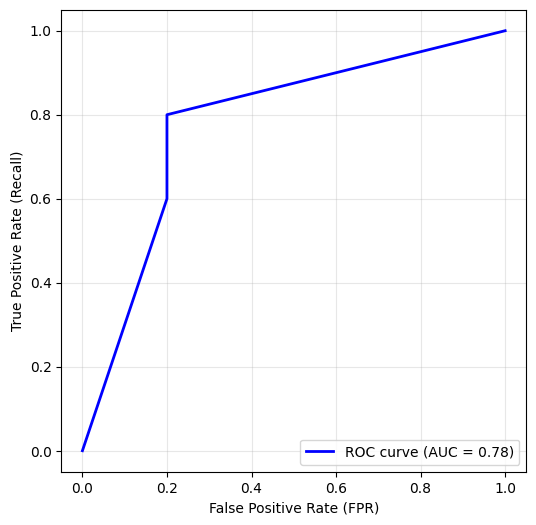

In [86]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_stat, pos_label='M')
roc_auc = roc_auc_score(y_test, y_pred_stat)
roc_df = pd.DataFrame({
    "FPR": fpr,
    "TPR": tpr,
    "Threshold": thresholds
})
print(roc_df.head(20))  # ispis prvih 10 redova
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall)")
#plt.title("ROC krivulja")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()